# Data Visualization
### Introduction to Seaborn: statistical data visualization
<table><border=0><tr><td><img src="http://seaborn.pydata.org/_static/scatterplot_matrix_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/errorband_lineplots_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/scatterplot_sizes_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/timeseries_facets_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/horizontal_boxplot_thumb.png" width="100"></td><td><img src="http://seaborn.pydata.org/_static/regression_marginals_thumb.png" width="100"></td></tr></table>

In today's class. we will learn how to create meaningful visualization that helps summarize the large amount of data effectively. We are introducing two libraries; matplotlib and seaborn.

[Seaborn_API_reference](http://seaborn.pydata.org/api.html)  
It's common to use `sns` as an alias for seaborn.

In [28]:
# importing the package(s) we want to use
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Pandas can separate columns based on different separator such as tabs, periods, or spaces. We can specify the delimiter by using the `sep=<sep keyword>` keyword argument.

In [29]:
### The input file is tab-delimited
tsv_Filepath = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/euk.tsv"
euk = pd.read_csv(<url filepath>)

In [30]:
### Using .head() and .tail() to see data content
euk.tail()

,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status
8297,Saccharomyces cerevisiae,Fungi,Ascomycetes,3.993920,38.2,-,-,2017,Scaffold
8298,Saccharomyces cerevisiae,Fungi,Ascomycetes,0.586761,38.5921,155,298,1992,Chromosome
8299,Saccharomyces cerevisiae,Fungi,Ascomycetes,12.020400,38.2971,-,-,2018,Chromosome
8300,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.960900,38.2413,-,-,2018,Chromosome
8301,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.820700,38.2536,-,-,2018,Chromosome


In [31]:
### .info() to provide information on the data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8302 entries, 0 to 8301
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Species             8302 non-null   object 
 1   Kingdom             8302 non-null   object 
 2   Class               8302 non-null   object 
 3   Size (Mb)           8302 non-null   float64
 4   GC%                 8302 non-null   object 
 5   Number of genes     8302 non-null   object 
 6   Number of proteins  8302 non-null   object 
 7   Publication year    8302 non-null   int64  
 8   Assembly status     8302 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 583.9+ KB


In [32]:
### What to do with '-' values?
## Change "-" into NAs
euk=pd.read_csv(<filepath>, sep=<separator>, na_values=[<missing values>])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8302 entries, 0 to 8301
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Species             8302 non-null   object 
 1   Kingdom             8302 non-null   object 
 2   Class               8302 non-null   object 
 3   Size (Mb)           8302 non-null   float64
 4   GC%                 7895 non-null   float64
 5   Number of genes     2372 non-null   float64
 6   Number of proteins  2371 non-null   float64
 7   Publication year    8302 non-null   int64  
 8   Assembly status     8302 non-null   object 
dtypes: float64(4), int64(1), object(4)
memory usage: 583.9+ KB


## How can we **visualize** the relationship between two variables?

It is hard for us to see patterns by reading large tables of data. For example, look at the following table that contains the genome size and the number of genes for reptiles. Can you see the relationship between genome size and the number of genes?

In [33]:
## Look at the data for class 'Reptiles' and 'Number of proteins'
euk[["Species","Size (Mb)","Number of genes"]] #not a subset of the df

,Species,Size (Mb),Number of genes
0,Emiliania huxleyi CCMP1516,167.676000,38549.0
1,Arabidopsis thaliana,119.669000,38311.0
2,Glycine max,979.046000,59847.0
3,Medicago truncatula,412.924000,37603.0
4,Solanum lycopersicum,828.349000,31200.0
...,...,...,...
8297,Saccharomyces cerevisiae,3.993920,NaN
8298,Saccharomyces cerevisiae,0.586761,155.0
8299,Saccharomyces cerevisiae,12.020400,NaN
8300,Saccharomyces cerevisiae,11.960900,NaN


## Seaborn visualization library
Using Seaborn function `relplot()` we can visualize the relationship between genome size and the number of genes in the entire eukaryote genome dataset. The names of the columns are selected for what we want on the X and Y axes.   

Use `;` (semicolon) to omit the stdout text of the plot.

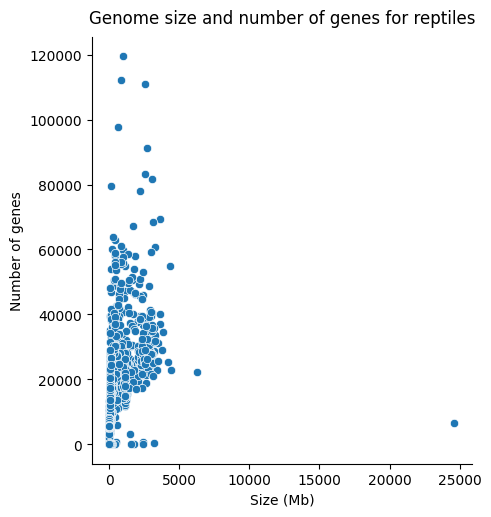

In [34]:
### Plot the relationship between "Size (Mb)" and "Number of genes")
sns.relplot(data=<df>, x=<colname>, y=<colname>)
plt.title("Genome size and number of genes for reptiles", pad=10);

### How do we see the data distribution if there is an outlier?
The chart above shows a problem commonly encountered in real life data: there is a single outlier with a massive genome size, which compresses the rest of the data points over to the left and makes it difficult to see the patterns.

We could fix this by manually setting the x axis limits using `plt.xlim(min, max)`. We can also use pandas to filter the dataframe and exclude very large genomes; `data = df[filtering statement]`.

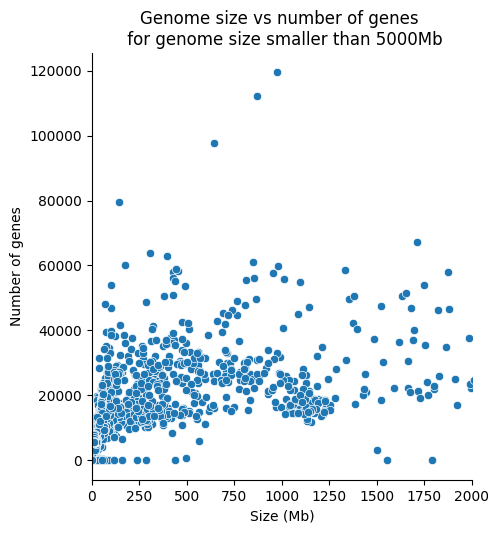

In [35]:
## Import pandas, seaborn, matplotlib if not already imported
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Define the file path and load the euk DataFrame correctly, handling NA values
tsv_Filepath = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/euk.tsv"
euk = pd.read_csv(tsv_Filepath, sep="\t", na_values=["-"])

## Method one to set the xlim boundaries
sns.relplot(
    data=euk,
    x="Size (Mb)",
    y="Number of genes"
)
plt.xlim(0, 2000) #Set lim for axis

## Method two filter the dataframe
sns.rel

plt.title("Genome size vs number of genes \n for genome size smaller than 5000Mb");

### Hue to colorize plot
We can map other properties to our plot. By setting the `hue=<colname>` argument we can specify which column we want to determine the color of each point. Here is another plot of genome size versus number of genes, this time limited to animals and with the GC percentage represented by **hue**.

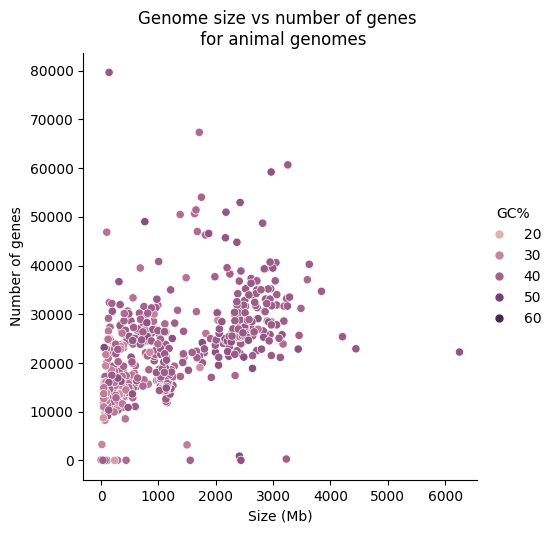

In [36]:
sns.relplot(
    data=euk[euk["Kingdom"]=="Animals"],
    x="Size (Mb)",
    y="Number of genes",
    hue=<colname>
)
plt.title("Genome size vs number of genes \n for animal genomes");

It is best to remove any rows with missing data before plotting our data so that it won't impact seaborn's ability to choose the color scales for the `hue`. We wil use panda's `dropna()` to do remove rows with missing data (null values).

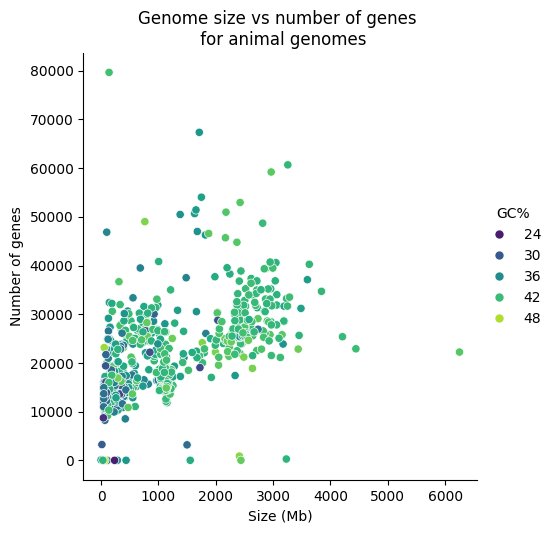

In [37]:
sns.relplot(
    data=euk[(euk["Kingdom"]=="Animals")].dropna(),
    x="Size (Mb)",
    y="Number of genes",
    hue="GC%",
    palette="viridis"
)
plt.title("Genome size vs number of genes \n for animal genomes");

## Size to separate data points baased on value
If we pick our mapping carefully, we can see multiple relationships between variables in a single plot. Unsurprisingly, larger genomes have more genes. We also noted that larger genomes have a more moderate GC percentages and that the extremes GC% (i.e. very light or dark colors) are over to the left of the chart.

Another property that we can map is the **size** of the data points. Let’s plot number of genes versus number of proteins and have the size of each point determined by the size of the genome. We use `size=<colname>` argument to map the size of the dot to the size of the genome. The argument sizes determines the minimum and maximum sizes of the points we want on the plot.

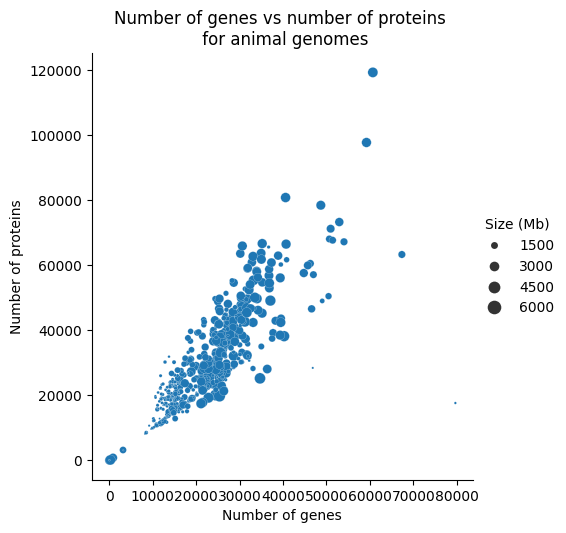

In [38]:
sns.relplot(
    data=euk[euk["Kingdom"]=="Animals"].dropna(),
    x="Number of genes",
    y="Number of proteins",
    size=<colname>,
    sizes=(min, max) #scale of size
)

plt.title("Number of genes vs number of proteins \n for animal genomes");

Let's map both GC% and genome size. We will use **size** to keep track of the genome size and **hue** to keep track of GC percentage.  
You can choose different palette for using different colors by setting the `palette=<color palette>` argument in `sns.relplot()`.

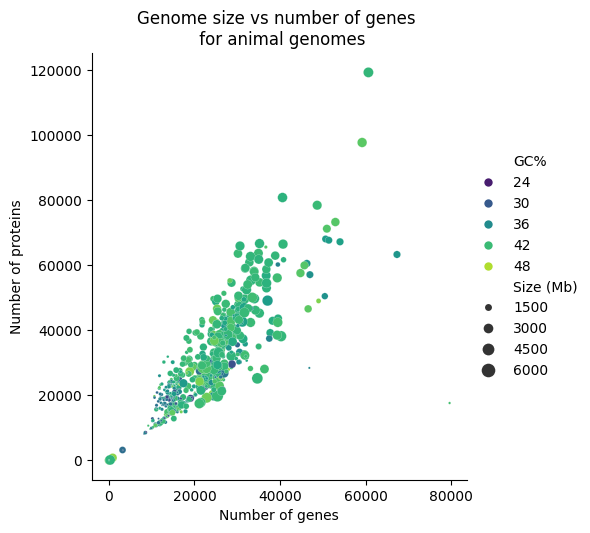

In [39]:
sns.relplot(
    data=euk[euk["Kingdom"]=="Animals"].dropna(),
    x="Number of genes",
    y="Number of proteins",
    size="Size (Mb)",
    hue="GC%",
    palette="viridis",
    sizes=(1, 100)
)
plt.title("Genome size vs number of genes \n for animal genomes");

## Question 15.1: Your turn to make a `relplot`.
Plot the relationship between the Number of proteins to Number of genes. Add additional parameter of GC% for size and Size (Mb) for hue.

Text(0.5, 1.0, 'Fungi genomes')

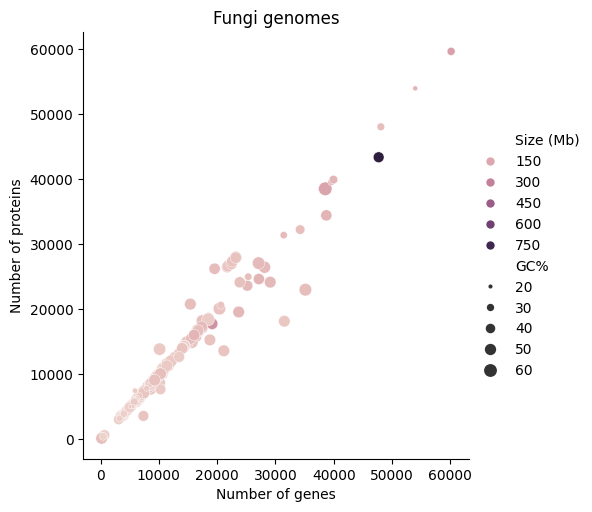

In [70]:
### Your code


## Categorical plot - `catplot`

In a previous lecture, we counted the number of rows using `value_counts()`. To visualize these counts, we can use seaborn's `catplot`. `catplot` takes in a long-form (tidy) dataframe for plotting. In a tidy dataframe, each column should correspond to a variable, and each row should correspond to an observation (data point).
  
The dataframe euk is in wide-form (summary). We will need to convert it to a long-form.

In [40]:
euk.head(3)

,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status
0,Emiliania huxleyi CCMP1516,Protists,Other Protists,167.676,64.5000,38549.0,38554.0,2013,Scaffold
1,Arabidopsis thaliana,Plants,Land Plants,119.669,36.0529,38311.0,48265.0,2001,Chromosome
2,Glycine max,Plants,Land Plants,979.046,35.1153,59847.0,71219.0,2010,Chromosome


In [41]:
### Create a tidy dataframe that contains the Class name of each observation of Animal
# euk[euk["Kingdom"] == "Animals"]["Class"].to_frame() #Using df to subset

animals_df = euk.Class[(euk.Kingdom == "Animals")].to_frame()
animals_df.columns = ['Animals']
animals_df

,Animals
34,Roundworms
35,Roundworms
36,Roundworms
37,Insects
38,Insects
...,...
7783,Mammals
7784,Mammals
7789,Mammals
7790,Mammals


There are many kinds of `catplot`. Here we are setting x-axis to Animal,`x='Animals'`, and `kind='count'` to plot a barplot that represents the counts of each unique obersvation (counts of unique types of Animals).

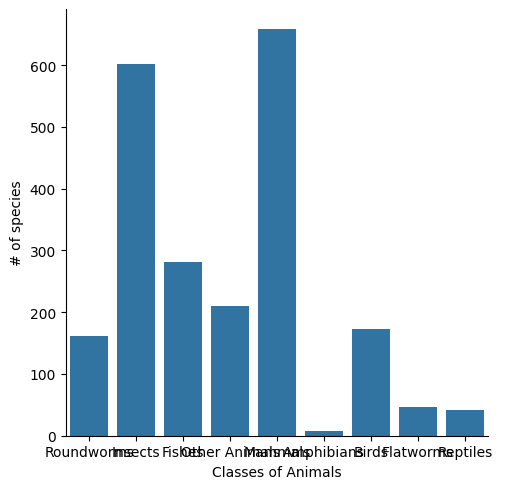

In [42]:
fig = sns.catplot(
    data=animals_df,
    x='Animals',
    kind='count'
)

fig.set_axis_labels('Classes of Animals', '# of species');

Using `set_xticklabels(rotation=<int>)`, we can rotate the x-axis label.

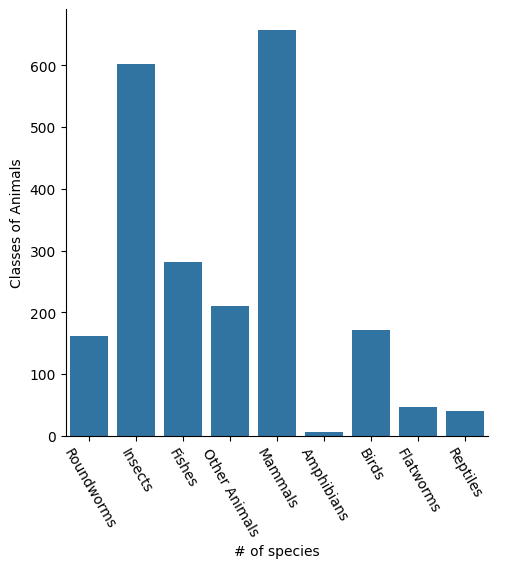

In [43]:
fig = sns.catplot(
    data=animals_df,
    x='Animals',
    kind='count'
)

fig.set_axis_labels('# of species', 'Classes of Animals');
fig.set_xticklabels(<rotation parameter>);

We can improve the plot by ordering the bars based on the height. We can also swap the x and y axis to avoid having overlapping data along the x-axis.

We will use `value_count()` which gives a resulting Series output. This Series is already sorted. Adding `.index` allows us to get the index of each Class of Animals in the sorted order.

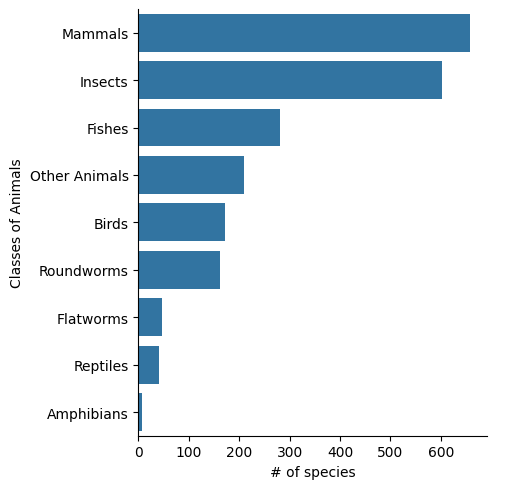

In [46]:
animals_df['Animals'].value_counts()

fig = sns.catplot(
    data=animals_df,
    y='Animals',
    kind='count',
    order=<sorted df>
)

fig.set_axis_labels('# of species', 'Classes of Animals');

## Question 15.2: Your turn to make a `catplot`.
Plot the number of types of unique plants.

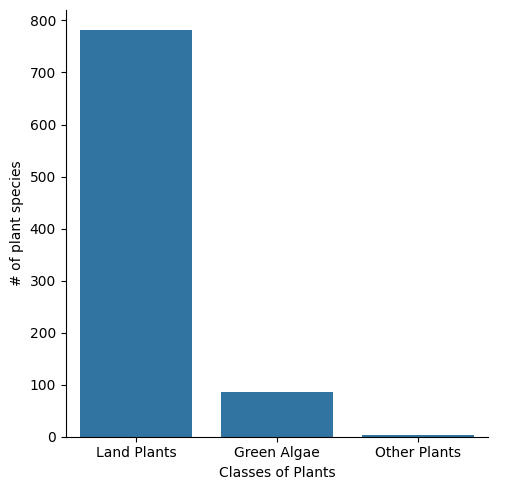

In [82]:
### Your code